# ED global GCB TRENDY — fire modeling (Model E)

**Model E burned-area formula as one pure function.** You control which data file feeds which factor.

| argument | factor | units |
|---|---|---|
| `dbar` | dryness onset + hyper-arid cutoff | dryness index |
| `t_air` | ignition sigmoid | degC |
| `p_ann` | precip floor (fuel can grow) | mm/yr |
| `p_month` | wet-month dampener | mm/month |
| `gpp_monthly` | fuel hump | GPP |
| `agb` | tropical canopy suppression (`None` disables) | kgC/m2 |
| `lat`, `lon` | selects 1 of 6 continental parameter sets | deg |

Returns monthly burned-**fraction** `(n_months, n_lat, n_lon)`, any resolution.

Verified bit-identical (max abs diff 0.0) to the paper repo's assembled Model-E field.
Ref: Owusu-Ansah et al., *Development and Optimization of a Global Fire Model Using Autoresearch AI*.

In [30]:
import sys,os,glob
import numpy as np
import xarray as xr
from datetime import datetime,timedelta
import rioxarray as rxr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm,trange
from datetime import datetime,timedelta
from calendar import monthrange
import cftime
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
print('done')


done


## 1. Model E function (self-contained — run this cell first)

In [1]:
#!/usr/bin/env python3
"""
ED_global_GCB_TRENDY_fire_modeling_v1.py

Model E burned-area formula (Owusu-Ansah et al., "Development and Optimization of
a Global Fire Model Using Autoresearch AI"), packaged as ONE pure function so the
caller controls exactly which data file feeds which factor.

    from ED_global_GCB_TRENDY_fire_modeling_v1 import model_E_burned_fraction
    ba = model_E_burned_fraction(dbar, t_air, p_ann, p_month, gpp_monthly, agb,
                                 lat, lon)

Everything is passed in explicitly; nothing is read from disk here. The mapping
from physical factor to required input is:

    factor in the formula            input argument     typical source
    -------------------------------  -----------------  ----------------------------
    dryness onset + hyper-arid off   dbar               accumulated dryness index
    ignition sigmoid                 t_air              monthly air temperature (degC)
    precip floor (fuel can grow)     p_ann              annual precip (mm/yr)
    precip dampener (wet month)      p_month            monthly precip (mm/month)
    fuel hump                        gpp_monthly        monthly GPP (fuel proxy)
    tropical canopy suppression      agb                above-ground biomass (kgC/m2)
    Africa fuel amplitude            gpp_fuel_capacity  time-mean GPP (defaults to
                                                        mean of gpp_monthly)
    region parameter selection       lat, lon           grid coordinates (deg)

Grids: all monthly fields are (n_months, n_lat, n_lon); agb same shape (or a single
(n_lat, n_lon) map, broadcast); lat is (n_lat,), lon is (n_lon,). Any resolution.

Output: monthly burned-AREA FRACTION, dimensionless in [0, 1), shape
(n_months, n_lat, n_lon). Multiply by cell area and sum over the 12 months of a
year to get annual burned area.

Notes on faithfulness to the paper code (DeveshParagiri/ed-autoresearch):
  * fire_C, the six continental parameter sets, the region boxes, the tropical
    gate (|lat| < 23.5), and the per-month transform 1 - exp(-min(rate, 5)/12)
    are reproduced exactly. Verified to match the repo's assembled Model-E field.
  * The Africa fuel amplitude uses a TIME-MEAN GPP ("fuel capacity"). By default
    that is the mean over all supplied months, which is a look-ahead climatology.
    For a prognostic / coupled run, pass gpp_fuel_capacity explicitly (e.g. a
    trailing running mean) so no future information leaks in.

Author: packaged for the GCB TRENDY archive, 2026-07.
"""
from __future__ import annotations

import numpy as np

# --- fitted parameters, one set per continent (verbatim from models/paper/E/) ---
# Region selection is first-match over REGION_ORDER by lon/lat box; every cell not
# claimed by a listed region uses 'fallback' (this is where N.America and Australia
# land in the paper's Model E).
REGION_ORDER = ("africa", "boreal", "samerica", "seasia", "europe")

REGION_BOX = {   # (lon_min, lon_max, lat_min, lat_max), degrees
    "africa":   (-20, 52, -36, 18),
    "boreal":   (40, 180, 48, 78),
    "samerica": (-82, -34, -56, 14),
    "seasia":   (60, 150, -11, 30),
    "europe":   (-12, 40, 36, 72),
}

PARAMS = {
    'africa': {"k1": 0.012840669372724958, "D_low": 5.351452349843333, "k2": 0.002884223471687844, "D_high": 2289.1315306837046, "fire_exp": 1.4126958348191876, "P_half": 221.2683656611821, "pre_dampen_half": 565.0116730717873, "gpp_af": 0.3002317246575309, "gpp_b": 0.0009153552948098625, "gpp_d": 229.41380323183625, "ign_k": 0.8599189552684969, "ign_c": 22.126836566118193, "trop_agb_crit": 10.215415653610627, "trop_k_veg": 6.45312300188076, "fuel_k": 4.710433409437072, "fuel_half": 11.781063202742125},
    'boreal': {"k1": 0.03648456083047798, "D_low": 236.79352040223893, "k2": 0.019383858782150494, "D_high": 7333.200379637292, "fire_exp": 1.5191397119156032, "P_half": 1.4551749476072258, "pre_dampen_half": 8.259599205585761, "gpp_af": 0.060029341913968644, "gpp_b": 5.0875243087016374e-05, "gpp_d": 1.4397852866783676, "ign_k": 0.0032383308053152635, "ign_c": 22.126836566118193, "trop_agb_crit": 1.8023542850487386, "trop_k_veg": 2.724170387400844, "fire_amp": 2.7806853670293616},
    'samerica': {"k1": 3.609310926766545e-05, "D_low": 1121.5915868662764, "k2": 0.003767022142229395, "D_high": 2298.2155660045737, "fire_exp": 1.4848387260494937, "P_half": 1265.0580856641704, "pre_dampen_half": 170.71098124594695, "gpp_af": 1.9706963379095486, "gpp_b": 0.00012118589392553798, "gpp_d": 96.93415502195788, "ign_k": 0.012480180965117606, "ign_c": 0.4177928311636542, "trop_agb_crit": 5.635210829694053, "trop_k_veg": 4.989748894578724, "fire_amp": 3.1543496524370136},
    'seasia': {"k1": 0.012840669372724958, "D_low": 12.105387404469584, "k2": 0.02065142557895925, "D_high": 262.11304189124235, "fire_exp": 1.7220686611084326, "P_half": 61.6097529474144, "pre_dampen_half": 16.009350908593582, "gpp_af": 0.016306190741524337, "gpp_b": 0.0012611058927054877, "gpp_d": 545.0253444559129, "ign_k": 0.8861249804463233, "ign_c": 1.4091459170104739, "trop_agb_crit": 29.831859755984098, "trop_k_veg": 6.168921645828263, "fire_amp": 2.042193818779288},
    'europe': {"k1": 0.08006837661379566, "D_low": 408.3047491580097, "k2": 4.69955602109909e-05, "D_high": 16780.50857913099, "fire_exp": 1.7505406131449859, "P_half": 9.580682294110435, "pre_dampen_half": 189.88136301569827, "gpp_af": 0.10098504976210308, "gpp_b": 0.002416023630607169, "gpp_d": 0.12027930570908299, "ign_k": 0.002357279455676982, "ign_c": 2.226297338331262, "trop_agb_crit": 12.708819454040446, "trop_k_veg": 0.828441460847982, "fire_amp": 1.8357623383234334},
    'fallback': {"k1": 0.028401063201780267, "D_low": 16.00237013173313, "k2": 0.00033271381912662167, "D_high": 2427.054417940131, "fire_exp": 1.5191397119156032, "P_half": 157.80309954142965, "pre_dampen_half": 8.259599205585761, "gpp_af": 0.03522602097143089, "gpp_b": 0.00012118589392553798, "gpp_d": 12.338826503601998, "ign_k": 3.965503094323014, "ign_c": 22.126836566118193, "trop_agb_crit": 5.526463318565575, "trop_k_veg": 2.724170387400844, "fire_amp": 5.44779717154213},
}

FIRE_MAX_RATE = 5.0     # annual fire rate cap (yr^-1) before the monthly transform
TROP_LAT = 23.5         # tropical canopy-suppression gate (|lat| < TROP_LAT)


# --- elementary response shapes (verbatim from reproduce_modelC.py) -------------
def _sig(x, k, c):      # rising sigmoid
    return 1.0 / (1.0 + np.exp(np.clip(-k * (x - c), -50, 50)))


def _supp(x, k, c):     # falling sigmoid
    return 1.0 / (1.0 + np.exp(np.clip(k * (x - c), -50, 50)))


def _hump(x, b, dec):   # rise-then-decay
    b = max(b, 1e-9)
    dec = max(dec, 1e-9)
    return (1.0 - np.exp(-np.clip(x / b, 0, 500))) * np.exp(-np.clip(x / dec, 0, 500))


def _fire_rate(p, dbar, t_air, p_ann, p_month, gpp_monthly, agb, lat1d, gpp_capacity):
    """Annual fire rate (yr^-1) for ONE parameter set over the whole grid.

    Faithful to reproduce_modelC.fire_C: base product of six [0,1] terms, optional
    tropical canopy suppression, then rate = product**fire_exp with an amplitude
    (fuel form if 'fuel_k' present, else scalar 'fire_amp')."""
    onset    = _sig(dbar,    p["k1"], p["D_low"])
    suppress = _supp(dbar,   p["k2"], p["D_high"])
    p_floor  = p_ann / (p_ann + p["P_half"] + 1e-12)
    p_damp   = 1.0 / (1.0 + p_month / (p["pre_dampen_half"] + 1e-12))
    gpp_mod  = _hump(p["gpp_af"] * gpp_monthly, p["gpp_b"], p["gpp_d"])
    ign_mod  = _sig(t_air, p["ign_k"], p["ign_c"])
    product  = onset * suppress * p_floor * p_damp * gpp_mod * ign_mod

    # tropical closed-canopy suppression, gated to |lat| < TROP_LAT
    if agb is not None and "trop_k_veg" in p and "trop_agb_crit" in p:
        trop = (np.abs(lat1d) < p.get("trop_lat", TROP_LAT)).astype(np.float32)[None, :, None]
        ratio = np.clip(agb / (p["trop_agb_crit"] + 1e-12), 0, None)
        canopy = 1.0 / (1.0 + np.power(ratio, p["trop_k_veg"]))
        product = product * (trop * canopy + (1.0 - trop))

    rate = np.power(np.clip(product, 0, None), p["fire_exp"])

    # amplitude: fuel form (rate grows with fuel capacity) or scalar multiplier
    if "fuel_k" in p:
        fuel = gpp_capacity / (gpp_capacity + p.get("fuel_half", 1.0) + 1e-9)
        rate = rate * (1.0 + p["fuel_k"] * fuel)
    elif "fire_amp" in p:
        rate = rate * p["fire_amp"]
    return rate.astype(np.float32)


def region_index(lat, lon):
    """Integer region id per cell: 0..len(REGION_ORDER)-1 for a listed region,
    -1 for fallback. First-match priority in REGION_ORDER (same as the paper).

    Returns an (n_lat, n_lon) int array. Exposed so the caller can inspect / plot
    which parameter set governs each cell."""
    lon2, lat2 = np.meshgrid(np.asarray(lon), np.asarray(lat))
    idx = np.full(lat2.shape, -1, dtype=np.int16)
    for r, name in enumerate(REGION_ORDER):
        lo0, lo1, la0, la1 = REGION_BOX[name]
        box = (lon2 >= lo0) & (lon2 <= lo1) & (lat2 >= la0) & (lat2 <= la1) & (idx < 0)
        idx[box] = r
    return idx


def model_E_burned_fraction(dbar, t_air, p_ann, p_month, gpp_monthly, agb,
                            lat, lon, gpp_fuel_capacity=None,
                            fire_max_rate=FIRE_MAX_RATE):
    """Model E monthly burned-area fraction.

    Parameters
    ----------
    dbar, t_air, p_ann, p_month, gpp_monthly : (n_months, n_lat, n_lon) float
        Dryness index, air temperature (degC), annual precip (mm/yr, repeated each
        month), monthly precip (mm/month), monthly GPP (fuel proxy).
    agb : (n_months, n_lat, n_lon) or (n_lat, n_lon) float, or None
        Above-ground biomass (kgC/m2) for tropical canopy suppression. If None,
        that term is disabled (fire is NOT removed from wet tropical forest).
    lat, lon : 1-D arrays (n_lat,), (n_lon,)
        Cell-centre coordinates in degrees. Used for region selection and the
        tropical gate. lon in [-180, 180].
    gpp_fuel_capacity : (n_lat, n_lon) or (n_months, n_lat, n_lon), optional
        Fuel capacity for the Africa amplitude term. Default = time-mean of
        gpp_monthly (a look-ahead climatology). Pass a running mean for a
        coupled / prognostic run.
    fire_max_rate : float
        Annual fire-rate cap before the monthly transform.

    Returns
    -------
    ba : (n_months, n_lat, n_lon) float32
        Monthly burned-area fraction in [0, 1).
    """
    dbar        = np.asarray(dbar, np.float32)
    t_air       = np.asarray(t_air, np.float32)
    p_ann       = np.asarray(p_ann, np.float32)
    p_month     = np.asarray(p_month, np.float32)
    gpp_monthly = np.asarray(gpp_monthly, np.float32)
    lat1d       = np.asarray(lat, np.float32)
    lon1d       = np.asarray(lon, np.float32)

    nt, nlat, nlon = gpp_monthly.shape
    for nm, a in [("dbar", dbar), ("t_air", t_air), ("p_ann", p_ann),
                  ("p_month", p_month)]:
        if a.shape != (nt, nlat, nlon):
            raise ValueError(f"{nm} shape {a.shape} != {(nt, nlat, nlon)}")
    if lat1d.shape != (nlat,) or lon1d.shape != (nlon,):
        raise ValueError(f"lat/lon must be ({nlat},)/({nlon},), got "
                         f"{lat1d.shape}/{lon1d.shape}")

    if agb is not None:
        agb = np.asarray(agb, np.float32)
        if agb.ndim == 2:
            agb = np.broadcast_to(agb, (nt, nlat, nlon))
        elif agb.shape != (nt, nlat, nlon):
            raise ValueError(f"agb shape {agb.shape} != {(nt, nlat, nlon)}")

    if gpp_fuel_capacity is None:
        gpp_capacity = gpp_monthly.mean(axis=0, keepdims=True)
    else:
        gpp_capacity = np.asarray(gpp_fuel_capacity, np.float32)
        if gpp_capacity.ndim == 2:
            gpp_capacity = gpp_capacity[None]
    gpp_capacity = np.clip(gpp_capacity, 0, None)

    # per-cell region id, then assemble the rate cell-by-cell from that region's params
    ridx = region_index(lat1d, lon1d)
    rate = np.empty((nt, nlat, nlon), np.float32)
    with np.errstate(over="ignore", invalid="ignore"):
        for r, name in enumerate(list(REGION_ORDER) + ["fallback"]):
            sel = (ridx == r) if name != "fallback" else (ridx == -1)
            if not sel.any():
                continue
            full = _fire_rate(PARAMS[name], dbar, t_air, p_ann, p_month,
                              gpp_monthly, agb, lat1d, gpp_capacity)
            rate[:, sel] = full[:, sel]

    rate = np.minimum(rate, fire_max_rate)
    ba = 1.0 - np.exp(-rate / 12.0)
    return ba.astype(np.float32)


## 2. Load inputs
Add your own loading here. Each variable must be `(n_months, n_lat, n_lon)`; `lat` is `(n_lat,)`, `lon` is `(n_lon,)` in degrees, `lon` in [-180, 180].

```python
# dbar        = ...   # dryness index
# t_air       = ...   # degC
# p_ann       = ...   # mm/yr
# p_month     = ...   # mm/month
# gpp_monthly = ...   # GPP (fuel proxy)
# agb         = ...   # kgC/m2  (or None to disable canopy suppression)
# lat, lon    = ...   # 1-D degree axes
```

In [37]:
# --- load your input fields here ---

# in_da_file = '/gpfs/data1/hurttgp/gel1/leima/AssignTask/ED_GEDI_ICESat2_initializaiton/Result/codex_projects/codex_ED_fire/output/handoff/global_baseline_modelC_inputs_1997-2016.nc'
# tmp_da = xr.open_dataset(in_da_file)
# dbar = tmp_da['D_bar']
# t_air = tmp_da['T_air']
# p_ann = tmp_da['P_ann']
# p_month = tmp_da['P_month']
# gpp_monthly = np.clip(tmp_da['GPP_month_ntrl'],0,None)*tmp_da['area_frac_ntrl']
# gpp_monthly += np.clip(tmp_da['GPP_month_scnd'],0,None)*tmp_da['area_frac_scnd']
# gpp_monthly += np.clip(tmp_da['GPP_month_past'],0,None)*tmp_da['area_frac_past']

# lat = tmp_da['lat']
# lon = tmp_da['lon']

in_da_file = '/gpfs/data1/hurttgp/gel1/leima/AssignTask/ED_GEDI_ICESat2_initializaiton/Result/GCB_TRENDY/GCB25_TRENDY_V14/ftp_upload/v1/S3/EDv3_S3_cVeg.nc'
tmp_da = xr.open_dataset(in_da_file)
tmp_da = tmp_da.rename({'latitude':'lat','longitude':'lon'})
tmp_da = tmp_da.sel(time=slice(datetime(1997,1,1),datetime(2016,12,31)))
tmp_da = [tmp_da.sel(time=[datetime(yr,12,15)]).assign_coords({'time':[datetime(yr,mon,15)]}) for yr in range(1997,2016+1) for mon in range(1,12+1)]
tmp_da = xr.concat(tmp_da,dim='time')
tmp_da = tmp_da.sortby('time',ascending=True)
agb = tmp_da['cVeg']*0.8

## 3. Compute burned area

In [ ]:
ba = model_E_burned_fraction(dbar, t_air, p_ann, p_month, gpp_monthly, agb, lat, lon)
ba = xr.DataArray(ba,dims=('time','lat','lon'),coords=dbar.coords)


# For a coupled/prognostic run, pass a trailing running-mean fuel capacity instead of the
# default look-ahead climatology:
# ba = model_E_burned_fraction(dbar, t_air, p_ann, p_month, gpp_monthly, agb, lat, lon,
#                              gpp_fuel_capacity=my_running_mean_gpp)


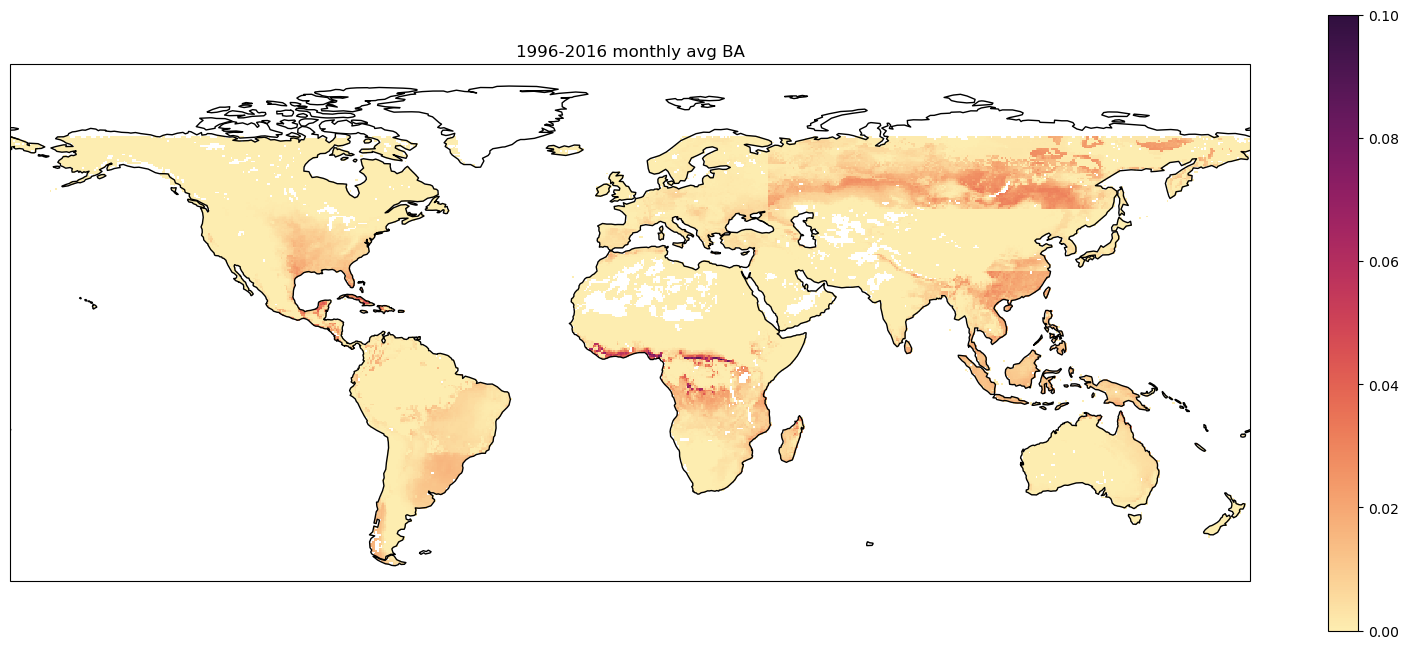

In [36]:
fig,ax = plt.subplots(figsize=(20,8),subplot_kw={'projection':ccrs.PlateCarree()})
ba.mean('time').plot.imshow(ax=ax,vmin=0,vmax=0.1,cmap='cmo.matter')
ax.add_feature(cfeature.COASTLINE)
ax.set_ylim([-60,90])
ax.set_title('1996-2016 monthly avg BA')
plt.show()

## 4. Evaluate BA
Add your own evaluation / plotting / scoring here.

In [ ]:
# --- evaluate BA here ---


## (optional) Self-test on synthetic data

In [ ]:
# Optional self-test on synthetic data (no files needed) -- run to sanity-check the function.
# standalone smoke test on synthetic data (no external files needed)
rng = np.random.default_rng(0)
nt, nlat, nlon = 24, 180, 360
lat = -89.5 + np.arange(nlat)
lon = -179.5 + np.arange(nlon)
dbar = rng.uniform(0, 3000, (nt, nlat, nlon)).astype("f4")
t_air = rng.uniform(-20, 35, (nt, nlat, nlon)).astype("f4")
p_ann = rng.uniform(50, 2500, (nt, nlat, nlon)).astype("f4")
p_month = rng.uniform(0, 300, (nt, nlat, nlon)).astype("f4")
gpp = rng.uniform(0, 3, (nt, nlat, nlon)).astype("f4")
agb = rng.uniform(0, 20, (nlat, nlon)).astype("f4")
ba = model_E_burned_fraction(dbar, t_air, p_ann, p_month, gpp, agb, lat, lon)
print("output shape", ba.shape, "dtype", ba.dtype)
print("range [%.3g, %.3g]  finite %.1f%%" % (
    np.nanmin(ba), np.nanmax(ba), 100 * np.isfinite(ba).mean()))
print("region ids present:", sorted(set(region_index(lat, lon).ravel().tolist())))
print("OK")
